# Import Library

<p>Pertama, kita mengimpor pustaka-pustaka yang diperlukan untuk menjalankan analisis data 🔎📊📊dan pemodelan machine learning 🤖. Dalam kode ini, kita menggunakan kode berikut. 👇👇</p>

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

<p>Pada tahapan awal, kita mengimpor pustaka-pustaka penting untuk: 👇👇</p>
<ul>
    <li>Analisis data 🔎📊📊</li>
    <li>serta Pemodelan Machine Learning 🤖🔧,
        <ul>
            <li>👆👆 Termasuk numpy dan pandas dalam manipulasi data,</li>
            <li>Serta sklearn untuk akses dataset dan alat pemodelan.</li>
        </ul>
    </li>
    <li>Dataset fetch_california_housing digunakan untuk mendapatkan data harga rumah 📃 yang kemudian dibagi menjadi set pelatihan dan pengujian. 🤖🧑‍🏫 & 🤖⚙️📝</li>
</ul>
<p>Data dinormalisasi menggunakan StandardScaler untuk memastikan fitur memiliki skala yang seragam. Model regresi Decision Tree (DecisionTreeRegressor) dilatih pada data pelatihan dan kinerjanya dievaluasi dengan mean_squared_error. Akhirnya, hasil analisis divisualisasikan menggunakan matplotlib.pyplot untuk memberikan gambaran yang jelas tentang performa model.</p>

# Memuat Dataset untuk Kasus Overfitting

<p>Selanjutnya, kita memuat dataset California Housing menggunakan fetch_california_housing() dari pustaka sklearn. Data ini disimpan dalam variabel X sebagai DataFrame untuk fitur-fitur dan y sebagai Series untuk target harga rumah. Selanjutnya, data dinormalisasi menggunakan StandardScaler untuk memastikan semua fitur memiliki skala yang seragam sehingga memudahkan proses pelatihan model.</p>
<p>Dataset kemudian dibagi menjadi dua bagian, yaitu data latih serta data uji dengan rasio 70% untuk pelatihan dan 30% untuk pengujian menggunakan train_test_split. Ini penting untuk mengevaluasi kinerja model pada data yang belum pernah dilihat sebelumnya.</p>

In [3]:
# Load dataset California housing
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Membagi dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

<p>Model DecisionTreeRegressor diinisialisasi dengan parameter max_depth=50 untuk membatasi kedalaman pohon keputusan 🌳🚧, yang sering kali digunakan untuk mengatasi overfitting.</p>
<ol>
    <li>Model ini 👆👆 kemudian dilatih pada ➡️ data latih 🤖🧑‍🏫 menggunakan metode fit().</li>
    <li>Setelah pelatihan 🤖🧑‍🏫✅✅, model digunakan untuk membuat prediksi pada data latih  🤖🧑‍🏫serta data uji 🤖⚙️📝, menghasilkan y_train_pred dan y_test_pred yang akan digunakan untuk evaluasi lebih lanjut 🔎📃📊 dari kinerja model 🤖⚙️.</li>
</ol>

In [4]:
# Inisialisasi model Decision Tree Regressor
model = DecisionTreeRegressor(max_depth=50, random_state=42)

# Melatih model dengan data latih
model.fit(X_train, y_train)

# Membuat prediksi untuk data latih dan data uji
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## Mendeteksi Overfitting

<p>Untuk mendeteksi overfitting 🔎⚠️, kita perlu membandingkan performa model 🔎🤖⚙️pada data latih dan data uji 🤖🧑‍🏫 & 🤖⚙️.</p>
<ul>
    <li>Overfitting terjadi ketika model bekerja sangat baik pada data latih, tetapi menunjukkan kinerja yang buruk pada data uji karena model terlalu menyesuaikan diri dengan data latih.</li>
</ul>

### 1. Evaluasi Performa pada Data Latih 🤖🧑‍🏫 dan Data Uji 🤖⚙️
<p>Pertama, kita menghitung Mean Squared Error (MSE) untuk data latih dan data uji.  MSE adalah metrik yang mengukur rata-rata kuadrat perbedaan antara nilai prediksi ❌✔️ dan nilai sebenarnya 🔢.</p>
<ul>
    <li>Semakin rendah nilai MSE, semakin baik performa model 🤖🔋💪💪 dalam memprediksi data ❌✔️🔋🔋🔋💪💪💪.</li>
</ul>

In [5]:
# Menghitung Mean Squared Error (MSE) untuk data latih dan data uji
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Menghasilkan hasil MSE
print(f'Training MSE: {train_mse}')
print(f'Test MSE: {test_mse}')

Training MSE: 9.904697258622977e-32
Test MSE: 0.5265256772490148


<p>Dalam kode ini 👆👆, mean_squared_error digunakan dalam menghitung MSE untuk prediksi 🔎❌✔️ pada data latih (y_train_pred) dan data uji (y_test_pred). Hasilnya 👆👆👆 kemudian ditampilkan untuk memberikan gambaran tentang performa model 🤖⚙️ pada kedua set data.</p>
<ul>
    <li>
        <b>Training MSE:</b>
        <p>MSE pada data latih menunjukkan seberapa baik model memprediksi data yang telah dilihat selama pelatihan 🤖🧑‍🏫.</p>
        <ul>
            <li>👆 Nilai MSE yang sangat rendah pada data latih <i>(9.904....e^-32, berarti 0.000000000.....9904)</i> dapat menunjukkan bahwa model terlalu menyesuaikan diri dengan data tersebut 🤖🧑‍🏫.</li>
        </ul>
    </li>
    <li>
        <b>Test MSE:</b>
        <p>MSE pada data uji menunjukkan seberapa baik model memprediksi data baru yang belum pernah dilihat sebelumnya.</p>
        <ul>
            <li>👆 Jika MSE dalam data uji jauh lebih tinggi dibandingkan dengan pada data latih, ini adalah indikator overfitting.</li>
        <ul>
    </li>
</ul>

<p>Dengan membandingkan MSE pada data latih dan data uji, kita dapat mengidentifikasi model mengalami overfitting atau tidak.</p>
<ul>
    <li>Model yang baik seharusnya memiliki nilai MSE relatif seimbang antara data latih dan data uji.</li>
    <li>Jika terjadi perbedaan yang signifikan, mungkin perlu mempertimbangkan untuk menyederhanakan model atau melakukan teknik regularisasi untuk mengurangi overfitting ⏬⏬.</li>
</ul>
<p>Hasilnya sebagai berikut :</p>

<p>Training MSE: 9.904697258622977e-32</p>
<p>Test MSE: 0.5265256772490148</p>

<p>Hasil evaluasi model 👆👆 menunjukkan bahwa:</p>
<ul>
    <li>Training MSE sebesar 9.90e-32 mengindikasikan performa yang sangat baik pada data latih 🤖🧑‍🏫 dengan kesalahan prediksi hampir mendekati nol.</li>
    <li>Namun, Test MSE sebesar 0.5265 yang:
        <ul>
            <li>Lebih tinggi menunjukkan bahwa model tidak dapat memprediksi data uji dengan akurat.</li>
        </ul>
    </li>
    <p>Perbedaan signifikan antara kedua nilai MSE ini 👆👆 mengindikasikan bahwa model mengalami overfitting, yaitu ketika model terlalu menyesuaikan diri dengan data latih sehingga gagal dalam generalisasi pada data baru.</p>
</ul>

### 2. Learning Curve

<p>Cara yang lain untuk mengidentifikasi overfitting adalah menampilkan learning curve.</p>
<ul>
    <li>Kode ini menggunakan fungsi learning_curve dari pustaka sklearn.model_selection untuk menghitung learning curve.</li>
</ul>
<p>Fungsi ini 👆 memproses model DecisionTreeRegressor pada berbagai ukuran set pelatihan 🤖🧑‍🏫 dan menghitung skor MSE 🧮 menggunakan cross-validation (dengan cv=5 yang berarti 5-fold cross-validation).</p>
<ul>
    <li>Parameter scoring='neg_mean_squared_error' digunakan untuk mengevaluasi model berdasarkan MSE dan n_jobs=-1 memungkinkan perhitungan paralel untuk mempercepat proses pelatihan 🤖🧑‍🏫⚙️⚙️👟👟.</li>
</ul>

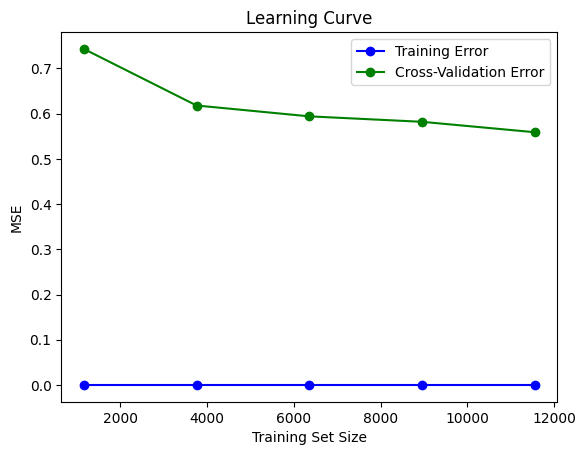

In [5]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# Menghitung learning curve
train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Menghitung rata - rata dan standar deviasi
train_mean = -np.mean(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)

# Plot learning curve
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label='Cross-Validation Error')
plt.title("Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.legend()
plt.show()

<p>Learning curve membantu kita memahami jika model sedang mengalami overfitting atau underfitting.</p>
<ul>
    <li>Jika kesalahan pelatihan sangat rendah, tetapi kesalahan validasi silang tetap tinggi atau tidak menurun seiring bertambahnya data pelatihan,
        <ul>
            <li>👆👆 ini mengindikasikan overfitting.</li>
        </ul>
    </li>
</ul>

<p>Setelah mengidentifikasi bahwa model mengalami overfitting 🔎⚠️,</p>
<div style="border-left: 2px solid white;">
    <ul style="margin-left: 2%;">
        <li>langkah selanjutnya adalah mencari solusi 🔎❔ untuk memperbaiki masalah tersebut</li>
        <li>dan meningkatkan kemampuan model dalam memprediksi data baru.</li>
    </ul>
    <p style="margin-left: 2%;">Apa saja cara yang bisa dilakukan❓ Simak terus, ya, materinya! 👇👇👇</p>
</div>

## Mengatasi Overfitting

<p>Mengatasi overfitting adalah langkah penting untuk memastikan model machine learning Anda dapat bekerja dengan baik tidak hanya pada data latih, tetapi juga dalam data baru. Overfitting terjadi ketika model terlalu menyesuaikan diri dengan data latih sehingga menghasilkan performa yang sangat baik pada data tersebut, tetapi buruk dalam data uji.</p>
<p>Dengan kata lain, model terlalu kompleks dan menangkap noise atau detail yang tidak relevan dalam data latih. Untuk menangani overfitting, kita dapat menggunakan berbagai teknik untuk menyederhanakan model dan meningkatkan kemampuannya dalam generalisasi.</p>
<div style="border: 2px solid white;">
    <p style="margin: 1%;">Di bawah ini, kita akan membahas beberapa metode yang dapat diterapkan untuk mengatasi masalah tersebut serta membuat model Anda lebih robust dan efektif!</p>
</div>

### 1. Cross Validation

<p>Salah satu cara efektif untuk mengatasi overfitting adalah penggunaan cross-validation.</p>
<ul>
    <li>Teknik ini 👆👆 membantu menilai seberapa baik model dapat menggeneralisasi data baru dengan membagi data pelatihan ➡️ menjadi beberapa subset</li>
    <li>dan melatih serta menguji model secara bergantian 🔁🔁 pada subset yang berbeda.</li>
    <li>👆 Ini memberikan gambaran yang lebih komprehensif (secara menyeluruh) tentang kinerja model dan mengurangi risiko overfitting.</li>
</ul>
<p>Berikut adalah implementasi cross-validation menggunakan 5-fold cross-validation dengan model yang telah dilatih.</p>

In [6]:
from sklearn.model_selection import cross_val_score

# Menggunakan cross-validation dengan 5 fold
cross_val_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# Menampilkan hasil cross-validation
print(f'Cross Validation MSE: {cross_val_scores.mean()}')

Cross Validation MSE: -0.5562691658603186


<p>cross_val_score mengevaluasi model menggunakan metode cross-validation dengan membagi data menjadi 5 bagian.</p>
<ul>
    <li>Pada setiap langkah 👣👣, model dilatih 🤖🧑‍🏫 dengan 4 bagian data dan diuji dengan 1 bagian sisanya.</li>
    <li>Proses ini 👆👆⚙️⚙️ dilakukan sebanyak 5 kali sehingga setiap bagian data 📃📃📃berkesempatan ➡️➡️ menjadi data uji. 🤖⚙️⚙️ </li>
</ul>
<p>Parameter scoring='neg_mean_squared_error' digunakan untuk menghitung Mean Squared Error (MSE) model</p>
<ul>
    <li>dan hasilnya dibalik 🔁 agar menjadi positif ➕➕.</li>
    <li>MSE dari setiap percobaan kemudian dirata-ratakan untuk memberikan gambaran kinerja model secara keseluruhan.</li>
</ul>

<p>Setelah menggunakan cross-validation 👆👆, hasil Cross-Validation MSE sebesar 0.556 didapatkan.</p>
<ul>
    <li>Sebelumnya ⏮️, model menunjukkan hasil Training MSE yang sangat kecil, yaitu 9.90 × 10⁻³² dan Test MSE sebesar 0.526.</li>
    <li>Hasil ini menunjukkan 👆👆 bahwa sebelum cross-validation, model mengalami overfitting karena performanya hampir sempurna pada data latih (training), 🤖🧑‍🏫⚙️⚙️✅✅✅ tetapi tidak begitu baik dalam data uji (test).</li>
</ul>

<p>Dengan cross-validation 👆👆, performa model diuji lebih menyeluruh dan lebih adil karena data dibagi menjadi beberapa bagian untuk diuji secara bergantian 🤖🔁🤖.</p>
<ul>
    <li>Hasil Cross-Validation MSE yang lebih mendekati Test MSE (0.556 vs. 0.526) menunjukkan bahwa model lebih konsisten dan mampu menghindari overfitting.
        <ul>
            <li>✅ Ini berarti model kini lebih baik dalam memprediksi data baru</li>
            <li>✅ dan lebih stabil ketika diuji dengan data yang berbeda.</li>
        </ul>
    </li>
</ul>
<p>Meskipun hasil Cross-Validation MSE sudah lebih stabil ✅, kita masih melihat adanya perbedaan cukup besar dengan Training MSE yang sangat kecil. Ini menunjukkan bahwa model kita masih belum optimal dan mungkin masih mengalami overfitting.</p>
<div style="border: 2px solid white;">
    <p style="margin: 1%;">Oleh karena itu, mari kita coba metode lain untuk memperbaiki model! 🤖🔧</p>
</div>


### 2. Regularization (Max Depth, Min Samples Split, Min Samples Leaf)


<p>Dalam langkah ini, kita mencoba cara lain, yaitu melakukan regularization atau regularisasi pada model Decision Tree untuk mengatasi overfitting.</p>
<ul>
    <li>Regularisasi dilakukan dengan mengurangi kedalaman pohon keputusan (max_depth) menjadi 5.</li>
    <li>👆 Ini bertujuan agar model tidak terlalu rumit dan lebih mampu menggeneralisasi data baru.</li>
</ul>

In [7]:
# Membuat model Decision Tree dengan kedalaman yang lebih kecil
model_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
model_reg.fit(X_train, y_train)

# Evaluasi pada data latih dan uji
y_train_pred_reg = model_reg.predict(X_train)
y_test_pred_reg = model_reg.predict(X_test)

# Hitung MSE
train_mse_reg = mean_squared_error(y_train, y_train_pred_reg)
test_mse_reg = mean_squared_error(y_test, y_test_pred_reg)

print(f"Training MSE (After Regularization): {train_mse_reg}")
print(f"Test MSE (After Regularization): {test_mse_reg}")

Training MSE (After Regularization): 0.4928096322147045
Test MSE (After Regularization): 0.5210801561811793


Sebelumnya, model Decision Tree tanpa regularisasi memberikan hasil sebagai berikut:<br>
**Training MSE:** $9.90 * 10^{32}$ <br>
**Test MSE:** $0.5265$


Ini menunjukkan 👆👆 bahwa model sangat cocok (overfitting) pada data latih dengan kesalahan yang sangat kecil, tetapi kesalahan dalam data uji cukup tinggi. Perbedaan yang besar ini menunjukkan bahwa model terlalu rumit dan tidak mampu menggeneralisasi dengan baik saat berhadapan dengan data baru.

Setelah menerapkan regularisasi pada model Decision Tree, hasil sebagai berikut didapatkan:<br>
**Training MSE (Setelah Regularisasi):** $0.4928$<br>
**Test MSE (Setelah Regularisasi):** $0.5211$

<p>Hasil ini menunjukkan 👆👆 peningkatan dibandingkan sebelumnya, yaitu perbedaan antara Training MSE dan Test MSE menjadi lebih kecil.</p>
<ul>
    <li>Ini berarti model telah menjadi lebih seimbang dan tidak lagi terlalu fokus pada data latih (overfitting) karena performa dalam data uji sekarang lebih mendekati performa pada data latih ✅✅.</li>
    <li>Regularisasi berhasil membuat model lebih mampu memprediksi data baru dengan lebih akurat. ✔️✔️✔️</li>
</ul>

### 3. Pruning (Pruning Manual pada Kedalaman Pohon)

<p>Cara ketiga, kita mencoba metode pruning untuk mengatasi overfitting pada Decision Tree.</p>
<ul>
    <li>Teknik yang digunakan adalah <span style="background-color:yellow; color:grey;">Cost Complexity Pruning dengan parameter ccp_alpha.</span></li>
    <li>Ini memungkinkan kita memangkas cabang-cabang pohon yang kurang penting 🌳🪹✂️.</li>
    <li><span style="background-color:gray;">Semakin besar nilai ccp_alpha</span>, semakin <span style="background-color:gray;">banyak pemangkasan dilakukan</span></li>
</ul>

In [10]:
# Menggunakan ccp_alpha untuk prunning (Cost Complexity Prunning)
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Melatih model dengan prunning
model_pruned = DecisionTreeRegressor(random_state=42, ccp_alpha=ccp_alphas[-2])
model_pruned.fit(X_train, y_train)

# Membuat prediksi
y_train_pred_pruned = model_pruned.predict(X_train)
y_test_pred_pruned = model_pruned.predict(X_test)

# Menghitung MSE
train_mse_pruned = mean_squared_error(y_train, y_train_pred_pruned)
test_mse_pruned = mean_squared_error(y_test, y_test_pred_pruned)

print(f'Pruned Model Training MSE: {train_mse_pruned}')
print(f'Pruned Model Test MSE: {test_mse_pruned}')

Pruned Model Training MSE: 0.9189620181001872
Pruned Model Test MSE: 0.9194598144703808


<p>Pada model Decision Tree <span style="background-color:red;"><b>tanpa regularisasi</b> seperti sebelumnya</span>, hasilnya berikut:</p>

- **Training MSE:** $9.90 * 10^{-32}$
- **Test MSE:** $0.5265$

<p><b>Hasil ini menunjukkan adanya overfitting yang sangat jelas</b>. MSE pada data latih hampir nol, artinya model sangat sesuai dengan data latih (overfitted), tetapi performanya dalam data uji tidak begitu baik dengan MSE sebesar 0.5265. Ini menunjukkan bahwa model tidak dapat melakukan generalisasi secara baik terhadap data baru karena terlalu rumit dan terlalu pas dengan data latih.</p>

<p>Setelah melakukan pruning pada model Decision Tree 👆👆, hasil yang diperoleh sebagai berikut:</p>

- **Pruned Model Training MSE:** 0.9189
- **Pruned Model Test MSE:** 0.9194

<p>Hasil ini menunjukkan bahwa setelah diterapkan pruning, kesalahan pada data latih dan data uji menjadi hampir sama.</p>
<ul>
    <li>Ini adalah tanda 👆👆 bahwa model telah berhasil mengurangi overfitting karena perbedaan antara MSE pada data latih dan data uji sudah sangat kecil.</li>
    <li>Meskipun nilai MSE pada data latih meningkat dibandingkan model sebelumnya, kemampuan model untuk melakukan generalisasi dalam data baru menjadi lebih baik dan lebih stabil ✅✅.</li>
</ul>

### 4. Data Augmentation

<p>Cara keempat yang bisa dicoba adalah augmentasi data.</p>
<ul>
    <li>Data augmentation adalah penggunaan teknik untuk meningkatkan kualitas dan kemampuan model dengan membuat variasi tambahan dari data yang sudah ada.</li>
</ul>
<p>Dalam contoh ini 👇👇, kita melakukan augmentasi dengan menambahkan sedikit noise atau gangguan  ➡️➡️ pada data latih.</p>
<ul>
    <li>Noise ini adalah gangguan acak yang tidak signifikan, tetapi cukup untuk memberikan variasi pada data latih kita.</li>
</ul>

In [6]:
# Menambahkan sedikit noise ke data sebagai augmentasi
X_train_aug = X_train + np.random.normal(0, 0.1, X_train.shape)

# Melatih ulang model dengan augmented data
model_aug = DecisionTreeRegressor(max_depth=10, random_state=42)
model_aug.fit(X_train_aug, y_train)

# Membuat prediksi
y_train_pred_aug = model_aug.predict(X_train_aug)
y_test_pred_aug = model_aug.predict(X_test)

# Menghitung MSE
train_mse_aug = mean_squared_error(y_train, y_train_pred_aug)
test_mse_aug = mean_squared_error(y_test, y_test_pred_aug)

print(f'Augmented Data Training MSE: {train_mse_aug}')
print(f'Augmented Data Test MSE: {test_mse_aug}')

Augmented Data Training MSE: 0.31459143782885457
Augmented Data Test MSE: 0.49998903062390765


<p>Setelah menerapkan data augmentation 👆👆 dengan menambahkan noise pada data latih, hasil yang diperoleh sebagai berikut. 👇👇</p>
<ul>
    <li><b>Augmented Data Training MSE:</b> 0.3193</li>
    <li><b>Augmented Data Test MSE:</b> 0.5219</li>
</ul>

<p>Sebelumnya, model tanpa augmentasi menunjukkan sebagai berikut.</p>

**Training MSE:** $9.90 * 10^{-32}$ (hampir nol)<br>
**Test MSE:** $0.5265$

<p>Dari hasil tersebut 👆, kita dapat melihat perubahan signifikan setelah data augmentation:</p>
<ul>
    <li>Sebelumnya, Training MSE sangat rendah, mendekati nol, menunjukkan overfitting yang besar.</li>
    <li>Dengan menerapkan data augmentation, Training MSE naik menjadi 0.3193.</li>
</ul>
<p>Ini menunjukkan bahwa model sekarang lebih general dan tidak terlalu pas dengan data latih.</p>
<ul>
    <li>Test MSE tetap hampir sama pada 0.5219, yang menunjukkan performa model dalam data uji tidak banyak berubah.</li>
</ul>
<p>Secara keseluruhan, data augmentation membantu mengurangi overfitting dengan membuat model lebih adaptif terhadap ➡️➡️ variasi dalam data latih meskipun hasil pada data uji tetap stabil.</p>

### 5. Dropout

<p>Cara selanjutnya yang bisa Anda pilih adalah dropout.</p>
<p>Dropout adalah teknik regulasi yang digunakan untuk <b>mencegah overfitting</b> dalam model machine learning, <b>khususnya neural networks</b>.</p>
<ul>
    <li>Teknik ini bekerja dengan "menghilangkan" beberapa neuron secara acak selama pelatihan sehingga model tidak terlalu bergantung pada neuron tertentu dan belajar untuk membuat keputusan berdasarkan fitur yang lebih robust.</li>
</ul>
<p>Namun, untuk masalah yang kita hadapi, yaitu model Decision Tree, kita tidak dapat menerapkan dropout secara langsung.</p>
<ul>
    <li>Sebagai gantinya, kita menggunakan pendekatan lain yang mirip, yaitu Random Forest.</li>
    <li>Random Forest adalah ensemble method yang menggunakan banyak pohon keputusan untuk meningkatkan kinerja model dan mengurangi overfitting.</li>
</ul>

In [8]:
from sklearn.ensemble import RandomForestRegressor

# Inisialisasi Random Forests dengan n_estimators (jumlah pohon)
model_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# Melatih model
model_rf.fit(X_train, y_train)

# Membuat prediksi
y_train_pred_rf = model_rf.predict(X_train)
y_test_pred_rf = model_rf.predict(X_test)

# Menghitung MSE
train_mse_rf = mean_squared_error(y_train, y_train_pred_rf)
test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)

print(f'Random Forest Training MSE: {train_mse_rf}')
print(f'Random Forest Test MSE: {test_mse_rf}')

Random Forest Training MSE: 0.16944949734743134
Random Forest Test MSE: 0.29446002390105996


<p>Hasil dari penerapan Random Forest sebagai berikut:</p>
<ul>
    <li><b>Training MSE:</b> 0.1694</li>
    <li><b>Test MSE:</b> 0.2945</li>
</ul>

Sebelumnya, model Decision Tree menunjukkan Training MSE yang sangat kecil, yaitu $9.90 × 10^{-32}$ dan Test MSE sebesar 0.5265; ini mengindikasikan adanya overfitting. Dengan menerapkan Random Forest, hasil MSE pada data latih adalah 0.1694 dan data uji adalah 0.2945.

<p>Meskipun MSE dalam data latih sedikit meningkat dibandingkan dengan model awal, MSE pada data uji menunjukkan penurunan yang signifikan.</p>
<ul>
    <li>🔎 Ini menandakan bahwa model Random Forest lebih baik dalam mengatasi overfitting dan memberikan hasil yang lebih stabil saat diterapkan pada data baru.</li>
</ul>

### 6. Early Stopping

# Memuat Dataset untuk Kasus Underfitting

<p>Untuk memahami fenomena underfitting, kita mulai dari memuat dataset dan menerapkan model yang sangat sederhana:</p>
<ul>
    <li>Pertama, kita menggunakan dataset Breast Cancer dari sklearn yang berisi informasi tentang fitur-fitur sampel kanker payudara serta label yang menunjukkan bahwa sampel tersebut jinak atau ganas.</li>
    <li>Dataset ini 📊📊👆👆 kemudian diubah menjadi format DataFrame dan Series untuk mempermudah analisis lebih lanjut.</li>
</ul>
<p>Selanjutnya, kita membagi dataset menjadi dua subset: data latih (70%) dan data uji (30%). Tujuan dari pembagian ini adalah melatih model pada satu subset dan mengujinya dalam subset berbeda sehingga kita bisa mengevaluasi performa model pada data yang belum pernah dilihat sebelumnya.</p>

In [4]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Load dataset (Breast Cancer Dataset)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Membagi dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

<p>Kita kemudian menerapkan model Decision Tree dengan kedalaman maksimum (max_depth) yang sangat rendah, yaitu 1.</p>
<ul>
    <li>Model dengan kedalaman ini 👆👆 cenderung terlalu sederhana dan tidak mampu menangkap pola kompleks dalam data, yang sering kali menyebabkan underfitting.</li>
    <li>Model ini 👆 dilatih dengan data latih 🤖🧑‍🏫, kemudian digunakan untuk membuat prediksi ❌✔️ pada ➡️ data latih 🤖🧑‍🏫 dan data uji 🤖⚙️. </li>
</ul>

![alt text](image/image_4.png)

In [5]:
# 2. Model Underfitting (Decision Tree dengan max_depth rendah)
model_underfit = DecisionTreeClassifier(max_depth=1, random_state=42)
model_underfit.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=1, random_state=42)

<p>Terakhir, setelah model dilatih 👆, kita menghasilkan prediksi, baik untuk data latih maupun data uji:</p>
<ul>
    <li>
        Hasil prediksi ini ❌✔️ akan digunakan untuk mengevaluasi kinerja model dan mengidentifikasi 🔎🔎🔎
        <ul>
            <li>Jika model mengalami underfitting yang ditandai dengan performa buruk pada kedua set data.</li>
        </ul>
    </li>
</ul>

In [8]:
# Prediksi
y_train_pred_underfit = model_underfit.predict(X_train)
y_test_pred_underfit = model_underfit.predict(X_test)

## Mendeteksi Underfitting

<p>Untuk mendeteksi underfitting, kita perlu membandingkan performa model pada data latih dan data uji.</p>
<ul>
    <li>Underfitting terjadi ketika model gagal menangkap pola mendalam pada data sehingga menunjukkan kinerja yang buruk dalam kedua data latih dan data uji.</li>
    <li>Ini 👆 biasanya terjadi ketika model terlalu sederhana untuk pemecahan masalah sehingga tidak mampu belajar dengan baik dari data yang tersedia.</li>
</ul>

### 1. Evaluasi Performa pada Data Latih dan Data Uji

<p>Langkah pertama dalam mendeteksi underfitting adalah mengevaluasi performa model pada data latih dan data uji.</p>
<ul>
    <li>Dalam hal ini 👆👆, kita menggunakan akurasi sebagai metrik untuk menilai seberapa baik model saat mengklasifikasikan data.</li>
</ul>
<p>Untuk model underfitting, kita menghitung akurasi pada data latih dan data uji dengan kode berikut: 👇👇</p>

In [9]:
# Evaluasi performa pada data latih dan data uji
train_acc_underfit = accuracy_score(y_train, y_train_pred_underfit)
test_acc_underfit = accuracy_score(y_test, y_test_pred_underfit)

print(f'Underfit Model Training Accuracy: {train_acc_underfit}')
print(f'Underfit Model Test Accuracy: {test_acc_underfit}')

Underfit Model Training Accuracy: 0.9246231155778895
Underfit Model Test Accuracy: 0.8947368421052632


<p>Hasil yang diperoleh adalah berikut:</p>
<ul>
    <li><b>Underfit Model Training Accuracy:</b> 0.9246</li>
    <li><b>Underfit Model Test Accuracy:</b> 0.8947</li>
</ul>

<p>Dari hasil ini, kita dapat melihat bahwa meskipun model memiliki akurasi yang cukup baik pada data latih (92.46%), akurasinya sedikit menurun dalam data uji (89.47%).</p>
<ul>
    <li>Perbedaan ini 👆 menunjukkan bahwa model tidak terlalu menyesuaikan diri dengan data latih, tetapi juga tidak menangkap pola yang cukup baik untuk memprediksi data uji dengan akurasi lebih tinggi.</li>
    <li>Ini adalah indikasi 👆 bahwa model mengalami underfitting.</li>
</ul>
<p>Intinya, si uji akurasinya lebih dibawah dari si latihan.</p>

### 2. Learning Curve 📈

<p>Learning curve 📈 adalah alat yang berguna untuk menganalisis bahwa model Anda berperforma baik dengan berbagai ukuran data latih.</p>
<ul>
    <li>Dengan learning curve 📈, Anda bisa melihat model 🔎🔎 mengalami underfitting atau overfitting.</li>
</ul>
<p>Dalam kasus underfitting, Anda bisa menggunakan learning curve untuk memeriksa performa model pada berbagai ukuran data latih.</p>
<ul>
    <li>Berikut adalah langkah-langkah dan kode yang digunakan: 👇👇</li>
</ul>

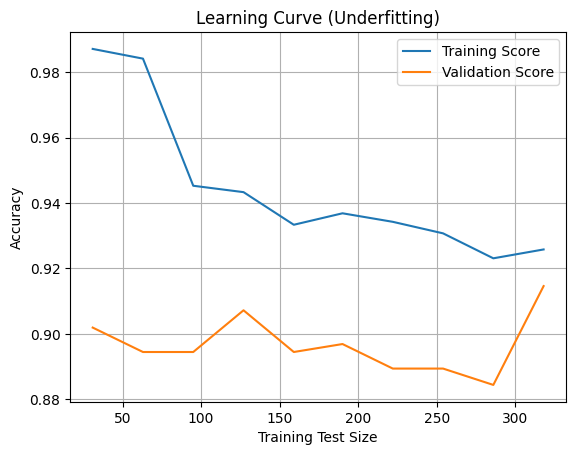

In [10]:
# Learning curve untuk memeriksa performa pada berbagai ukuran data latih
train_sizes, train_scores, test_scores = learning_curve(model_underfit, X_train, y_train, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Plot learning curve
plt.figure()
plt.plot(train_sizes, train_scores_mean, label='Training Score')
plt.plot(train_sizes, test_scores_mean, label='Validation Score')
plt.ylabel('Accuracy')
plt.xlabel('Training Test Size')
plt.title('Learning Curve (Underfitting)')
plt.legend()
plt.grid(True)
plt.show()

<p>Jika learning curve menunjukkan bahwa baik skor pelatihan maupun skor validasi tidak meningkat secara signifikan dengan bertambahnya ukuran data, ini mengindikasikan bahwa model mungkin tidak cukup kompleks untuk menangkap pola dalam data</p>
<ul>
    <li>👆 Ini merupakan tanda underfitting.</li>
    <li>Grafik ini 📈 membantu Anda memahami bahwa model mungkin terlalu sederhana dan menunjukkan perlunya model yang lebih kompleks untuk meningkatkan performa.</li>
</ul>

### 3. Pemeriksaan Kompleksitas Model 🔍

<p>Jika learning curve menunjukkan bahwa baik training score maupun validation score tidak meningkat secara signifikan dengan bertambahnya ukuran data, ini adalah tanda bahwa model Anda tidak cukup kompleks untuk menangkap pola-pola dalam data.</p>
<ul>
    <li>👆 Ini adalah indikasi dari underfitting bahwa model terlalu sederhana.</li>
    <li>Grafik ini membantu Anda melihat bahwa model mungkin perlu ditingkatkan agar lebih mampu menangani kompleksitas data dan meningkatkan performanya.</li>
</ul>

In [13]:
# Membandingkan dengan model yang lebih kompleks (e.g., max_depth=5)
model_complex = DecisionTreeClassifier(max_depth=5, random_state=42)
model_complex.fit(X_train, y_train)

y_train_pred_complex = model_complex.predict(X_train)
y_test_pred_complex = model_complex.predict(X_test)

train_acc_complex = accuracy_score(y_train, y_train_pred_complex)
test_acc_complex = accuracy_score(y_test, y_test_pred_complex)

print(f'Complex Model Training Accuracy: {train_acc_complex}')
print(f'Complex Model Test Accuracy: {test_acc_complex}')

Complex Model Training Accuracy: 0.9949748743718593
Complex Model Test Accuracy: 0.9532163742690059


<p>Dengan menggunakan model yang lebih kompleks, yakni dengan max_depth=5, perubahan signifikan dalam hasil terlihat sebagai berikut:</p>
<ul>
    <li><b>Akurasi Model Kompleks pada Data Latih:</b> 0.995</li>
    <li><b>Akurasi Model Kompleks pada Data Uji:</b> 0.953</li>
</ul>

<p>Model sederhana yang mengalami underfitting sebelumnya hanya mencapai akurasi pelatihan sekitar 0.925 dan akurasi uji sekitar 0.895. Model yang lebih kompleks ini hampir mencapai akurasi sempurna pada data latih dan tetap sangat bagus dalam data uji.</p>
<p>Perbedaan besar ini 👆👆 menunjukkan bahwa model yang lebih kompleks dapat menangkap pola data dengan lebih baik dan memperbaiki masalah underfitting pada model yang lebih sederhana.</p>
<ul>
    <li>👆 Dengan demikian, jika model Anda terasa terlalu sederhana, pertimbangkan untuk mencoba model yang lebih kompleks guna meningkatkan performa, ya!</li>
</ul>

## Mengatasi Underfitting

<p>Mengatasi underfitting adalah kunci untuk meningkatkan performa model yang tidak cukup menangkap pola dalam data.</p>
<ul>
    <li>Ini sering terlihat dari hasil akurasi yang rendah, baik pada data latih maupun data uji. </li>
    <li>Underfitting terjadi ketika model terlalu sederhana untuk memodelkan hubungan yang kompleks dalam data sehingga menghasilkan prediksi kurang akurat.</li>
</ul>
<p>Dalam mengatasi underfitting, tujuan kita adalah menyempurnakan model sehingga dapat menangkap pola-pola yang ada dengan lebih baik.</p>
<ul>
    <li>Berbagai teknik dapat digunakan untuk meningkatkan kapasitas model dan performanya.</li>
</ul>
<p>Di bawah ini 👇👇, kita akan menjelaskan beberapa metode yang bisa diterapkan untuk mengatasi underfitting dan meningkatkan kemampuan model dalam memprediksi data secara lebih efektif. 🔎❌✔️✅✅</p>

### 1. Gunakan Model Lebih Kompleks

<p>Ketika Anda menghadapi masalah underfitting, salah satu langkah pertama yang bisa dicoba adalah menggunakan model lebih kompleks.</p>
<ul>
    <li>Underfitting terjadi ketika model terlalu sederhana dan tidak dapat menangkap pola dalam data sehingga hasil prediksinya kurang optimal, baik pada data latih maupun data uji.</li>
</ul>
<p>Sebelumnya, hasil akurasi model underfitting adalah berikut:</p>
<ul>
    <li><b>Akurasi Training Underfitting:</b> 0.9246</li>
    <li><b>Akurasi Test Underfitting:</b> 0.8947</li>
</ul>
<p>Untuk mengatasi masalah ini 👆, Anda bisa meningkatkan kompleksitas model:</p>
<ul>
    <li>Dalam contoh ini, kita menggunakan model DecisionTreeClassifier dengan parameter max_depth yang lebih besar, yaitu 10.</li>
    <li>Ini memberikan kapasitas yang lebih besar pada model dan memungkinkan model untuk menangkap lebih banyak pola dalam data.</li>
</ul>

<p>👇 Berikut adalah kode untuk melatih dan mengevaluasi model yang lebih kompleks:</p>

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Menggunakan model yang lebih kompleks dengan max_depth lebih besar
complex_model = DecisionTreeClassifier(max_depth=10, random_state=42)
complex_model.fit(X_train, y_train)

# Prediksi pada data latih dan uji
y_train_pred_complex = complex_model.predict(X_train)
y_test_pred_complex = complex_model.predict(X_test)

# Evaluasi performa
train_acc_complex = accuracy_score(y_train, y_train_pred_complex)
test_acc_complex = accuracy_score(y_test, y_test_pred_complex)

print(f"Training Accuracy Complex: {train_acc_complex}")
print(f"Test Accuracy Complex: {test_acc_complex}")

Training Accuracy Complex: 1.0
Test Accuracy Complex: 0.9415204678362573


<p>Hasil setelah menerapkan model yang lebih kompleks adalah berikut:</p>
<ul>
    <li><b>Training Accuracy:</b> 1.0</li>
    <li><b>Test Accuracy:</b> 0.9415</li>
</ul>
<p>Dengan menggunakan model yang lebih kompleks, Anda akan melihat peningkatan signifikan dalam akurasi, baik pada data latih maupun data uji.</p>
<ul>
    <li>👆 Ini menunjukkan bahwa model sekarang lebih mampu menangkap pola data dan mengatasi masalah underfitting yang sebelumnya ada.</li>
</ul>

### 2. Tambahkan Lebih Banyak Fitur (Feature Engineering dengan PCA)

<p>Metode kedua untuk mengatasi underfitting adalah menambahkan lebih banyak fitur ke dalam model melalui teknik feature engineering.</p>
<ul>
    <li>Salah satu cara untuk melakukannya adalah menggunakan principal component analysis (PCA).</li>
</ul>
<p>PCA adalah teknik untuk mereduksi dimensi data sambil mempertahankan informasi yang paling penting.</p>
<ul>
    <li>Dengan menghasilkan fitur baru dari data asli, PCA dapat membantu model dalam memahami pola yang lebih kompleks.</li>
</ul>
<p>Sebelumnya, hasil akurasi model underfitting sebagai berikut.</p>
<ul>
    <li><b>Akurasi Training Underfitting:</b> 0.9246</li>
    <li><b>Akurasi Test Underfitting:</b> 0.8947</li>
</ul>
<p>Dalam mencoba pendekatan ini, pertama-tama kita normalisasi data dengan StandardScaler,</p>
<ul>
    <li>kemudian menerapkan PCA untuk menghasilkan fitur baru dari data yang telah dinormalisasi. </li>
    <li>Setelah itu, kita melatih model DecisionTreeClassifier yang sama dengan parameter max_depth 10 menggunakan fitur hasil PCA.</li>
</ul>
<p>Berikut adalah langkah-langkah dan kode untuk menerapkan PCA:</p>

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Normalisasi Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA untuk mengurangi dimensi atau menghasilkan fitur baru
pca = PCA(n_components=5) # Menghasilkan fitur baru dari data asli
X_pca = pca.fit_transform(X_scaled)

# Membagi data menjadi data latih dan data uji
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# Model dengan fitur hasil PCA
complex_model_pca = DecisionTreeClassifier(max_depth=10, random_state=42)
complex_model_pca.fit(X_train_pca, y_train_pca)

# Prediksi pada data latih dan uji
y_train_pred_pca = complex_model_pca.predict(X_train_pca)
y_test_pred_pca = complex_model_pca.predict(X_test_pca)

# Evaluasi performa
train_acc_pca = accuracy_score(y_train_pca, y_train_pred_pca)
test_acc_pca = accuracy_score(y_test_pca, y_test_pred_pca)

print(f"Training Accuracy (PCA): {train_acc_pca}")
print(f"Testing Accuracy (PCA): {test_acc_pca}")

Training Accuracy (PCA): 1.0
Testing Accuracy (PCA): 0.9415204678362573


<p>Hasil yang diperoleh setelah menggunakan fitur hasil PCA sebagai berikut:</p>
<ul>
    <li><b>Training Accuracy (PCA):</b> 1.0</li>
    <li><b>Test Accuracy (PCA):</b> 0.9415</li>
</ul>

<p>Dengan menerapkan PCA serta menambahkan fitur baru 👆👆, kita bisa melihat bahwa akurasi model pada data latih dan data uji meningkat secara signifikan. Ini menunjukkan bahwa model sekarang lebih mampu menangkap pola-pola kompleks dalam data sehingga mengurangi masalah underfitting yang ada sebelumnya.</p>

### 3. Hyperparameter Tuning Menggunakan GridSearchCV

<p>Langkah ketiga untuk mengatasi underfitting adalah melakukan hyperparameter tuning pada model.</p>
<ul>
    <li>Hyperparameter tuning adalah proses mencari kombinasi terbaik dari parameter model untuk meningkatkan kinerja model.</li>
    <li>Salah satu alat yang berguna untuk tugas ini adalah GridSearchCV.</li>
    <li>Ini memungkinkan kita mengeksplorasi berbagai kombinasi hyperparameter secara sistematis.</li>
</ul>
<p>⏮️ Sebelumnya, hasil akurasi model underfitting adalah berikut.</p>
<ul>
    <li><b>Akurasi Training Underfitting:</b> 0.9246</li>
    <li><b>Akurasi Test Underfitting:</b> 0.8947</li>
</ul>

<p>Dengan GridSearchCV, kita dapat mencari parameter terbaik 🔎🔎untuk model DecisionTreeClassifier.</p>
<ul>
    <li>Kita menentukan grid pencarian untuk hyperparameter, seperti max_depth,` min_samples_split`, dan min_samples_leaf.</li>
    <li>⚙️⚙️ Proses ini melibatkan evaluasi berbagai kombinasi parameter menggunakan teknik cross-validation untuk menemukan konfigurasi yang optimal ✅✅.</li>
</ul>
<p>👇👇 Berikut adalah kode untuk melakukan hyperparameter tuning.</p>

In [18]:
from sklearn.model_selection import GridSearchCV

# Grid Search untuk hyperparameter tuning
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid, cv=5, scoring='accuracy')

# Melakukan pencarian hyperparameter terbaik
grid_search.fit(X_train, y_train)

# Hyperparameter terbaik
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Prediksi dengan model terbaik
y_train_pred_best = best_model.predict(X_train)
y_test_pred_best = best_model.predict(X_test)

# Evaluasi performa
train_acc_best = accuracy_score(y_train, y_train_pred_best)
test_acc_best = accuracy_score(y_test, y_test_pred_best)

print(f"Training Accuracy (Best Model): {train_acc_best}")
print(f"Test Accuracy (Best Model): {test_acc_best}")
print(f"Best Params: {best_params}")

Training Accuracy (Best Model): 0.9949748743718593
Test Accuracy (Best Model): 0.9532163742690059
Best Params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


Inget, pada bagian print, jangan single quote f'', tetapi pakai double quote f"".

<p>Hasil yang diperoleh setelah hyperparameter tuning adalah berikut:</p>
<ul>
    <li><b>Training Accuracy (Best Model):</b> 0.9950</li>
    <li><b>Test Accuracy (Best Model):</b> 0.9532</li>
    <li><b>Best Params:</b> {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}</li>
</ul>

<p>Dengan melakukan hyperparameter tuning, kita bisa melihat peningkatan signifikan dalam akurasi model pada data latih dan data uji.</p>
<ul>
    <li>Ini menunjukkan bahwa model kini lebih sesuai dengan data dan dapat menangani pola yang lebih kompleks serta mengatasi masalah underfitting sebelumnya.</li>
</ul>

### 4. Perbaiki Preprocessing Data

<p>Langkah keempat dalam mengatasi underfitting adalah memperbaiki preprocessing data</p>
<ul>
    <li>Preprocessing yang baik sangat penting karena dapat memengaruhi kinerja model secara signifikan.</li>
    <li>Salah satu teknik penting adalah normalisasi data.</li>
    <li>Ini memastikan bahwa fitur memiliki skala yang sama 🎚️⚖️ sehingga model dapat belajar dengan lebih efektif.</li>
</ul>
<p>Sebelumnya, hasil akurasi model underfitting adalah berikut:</p>
<ul>
    <li><b>Akurasi Training Underfitting:</b> 0.9246</li>
    <li><b>Akurasi Test Underfitting:</b> 0.8947</li>
</ul>
<p>Untuk meningkatkan performa model 🤖⚙️➕➕, kita melakukan normalisasi ulang pada data.</p>
<ul>
    <li>Anda bisa menggunakan StandardScaler untuk menstandardisasi fitur sehingga memiliki rata-rata 0 dan standar deviasi 1.</li>
    <li>Setelah itu, kita membagi data menjadi data latih 🤖🧑‍🏫 dan data uji 🤖⚙️, kemudian melatih model DecisionTreeClassifier dengan parameter max_depth yang lebih besar.</li>
</ul>
<p>👇 Berikut adalah kode untuk preprocessing ulang dan evaluasi model:</p>

In [19]:
# Melakukan normalisasi ulang dengan scaler
scaler = StandardScaler()
X_scaled_new = scaler.fit_transform(X)

# Membagi ulang data latih dan uji
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(X_scaled_new, y, test_size=0.3, random_state=42)

# Model setelah preprocessing data lebih baik
model_after_scaling = DecisionTreeClassifier(max_depth=10, random_state=42)
model_after_scaling.fit(X_train_scaled, y_train_scaled)

# Prediksi
y_train_pred_scaled = model_after_scaling.predict(X_train_scaled)
y_test_pred_scaled = model_after_scaling.predict(X_test_scaled)

# Evaluasi performa
train_acc_scaled = accuracy_score(y_train_scaled, y_train_pred_scaled)
test_acc_scaled = accuracy_score(y_test_scaled, y_test_pred_scaled)

print(f"Training Accuracy (After Scaling): {train_acc_scaled}")
print(f"Test Accuracy (After Scaling): {test_acc_scaled}")

Training Accuracy (After Scaling): 1.0
Test Accuracy (After Scaling): 0.9415204678362573


<p>Hasil yang diperoleh setelah perbaikan preprocessing adalah berikut:</p>
<ul>
    <li><b>Training Accuracy (After Scaling):</b> 1.0</li>
    <li><b>Test Accuracy (After Scaling):</b> 0.9415</li>
</ul>

<p>Dengan perbaikan preprocessing data, kita melihat bahwa akurasi model pada data latih tetap tinggi dan akurasi dalam data uji juga meningkat.</p>
<ul>
    <li>
        👆 Ini menunjukkan bahwa preprocessing yang lebih baik membantu model untuk:
        <ul>
            <li>Belajar lebih efektif 🤖🧑‍🏫✅</li>
            <li>dan memberikan performa lebih baik 🤖⚙️✅</li>
            <li>serta mengatasi masalah underfitting sebelumnya ⚖️.</li>
        </ul>
    </li>
</ul>

### 5. Tambahkan Data Latih

<p>Langkah kelima untuk mengatasi underfitting adalah menambahkan lebih banyak data latih 🤖🧑‍🏫📃📃📃➕➕➕.</p>
<ul>
    <li>👆 Dengan meningkatkan jumlah data latih, model memiliki lebih banyak informasi untuk belajar dan dapat meningkatkan kemampuannya dalam mengenali pola yang lebih kompleks.</li>
</ul>
<p>⏮️ Sebelumnya, hasil akurasi model underfitting adalah berikut.</p>
<ul>
    <li><b>Akurasi Training Underfitting:</b> 0.9246</li>
    <li><b>Akurasi Test Underfitting:</b> 0.8947</li>
</ul>
<p>Untuk memperbaiki performa model 🤖🔧, kita dapat memperbesar ukuran data latih 🤖🧑‍🏫➕➕➕.</p>
<ul>
    <li>Kita membagi ulang data dengan meningkatkan proporsi data latih 🤖🧑‍🏫➕➕➕ dan mengurangi ukuran data uji 🤖⚙️➖➖➖.</li>
    <li>Kemudian, kita melatih model DecisionTreeClassifier dengan parameter max_depth lebih besar menggunakan data latih yang lebih besar.</li>
</ul>
<p>Berikut adalah kode untuk menambah data latih dan evaluasi model:</p>

In [20]:
# Membagi ulang data dengan lebih banyak data latih (menambah ukuran training set)
X_train_more_data, X_test_less_data, y_train_more_data, y_test_less_data = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Model dengan lebih banyak data latih
model_more_data = DecisionTreeClassifier(max_depth=10, random_state=42)
model_more_data.fit(X_train_more_data, y_train_more_data)

# Prediksi
y_train_pred_more_data = model_more_data.predict(X_train_more_data)
y_test_pred_more_data = model_more_data.predict(X_test_less_data)

# Evaluasi performa
train_acc_more_data = accuracy_score(y_train_more_data, y_train_pred_more_data)
test_acc_more_data = accuracy_score(y_test_less_data, y_test_pred_more_data)

print(f"Training Accuracy (More Data): {train_acc_more_data}")
print(f"Test Accuracy (More Data): {test_acc_more_data}")

Training Accuracy (More Data): 1.0
Test Accuracy (More Data): 0.9473684210526315


<p>Hasil yang diperoleh setelah menambahkan data latih adalah berikut:</p>
<ul>
    <li><b>Training Accuracy (More Data):</b> 1.0</li>
    <li><b>Test Accuracy (More Data):</b> 0.9474</li>
</ul>
<p>Dengan menambah ukuran data latih, akurasi model dalam data latih tetap tinggi dan akurasi pada data uji juga mengalami peningkatan.</p>
<ul>
    <li>👆 Ini menunjukkan bahwa dengan data latih yang lebih banyak, model dapat menangkap pola lebih kompleks dan memberikan performa lebih baik. 🤖⚙️✅</li>
    <li>Ini membantu mengatasi masalah underfitting yang ada sebelumnya.</li>
</ul>